# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Pasion, Kyla Zarina R.
- _Student No._: 2024-09224
- _Section_: THR-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.


### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

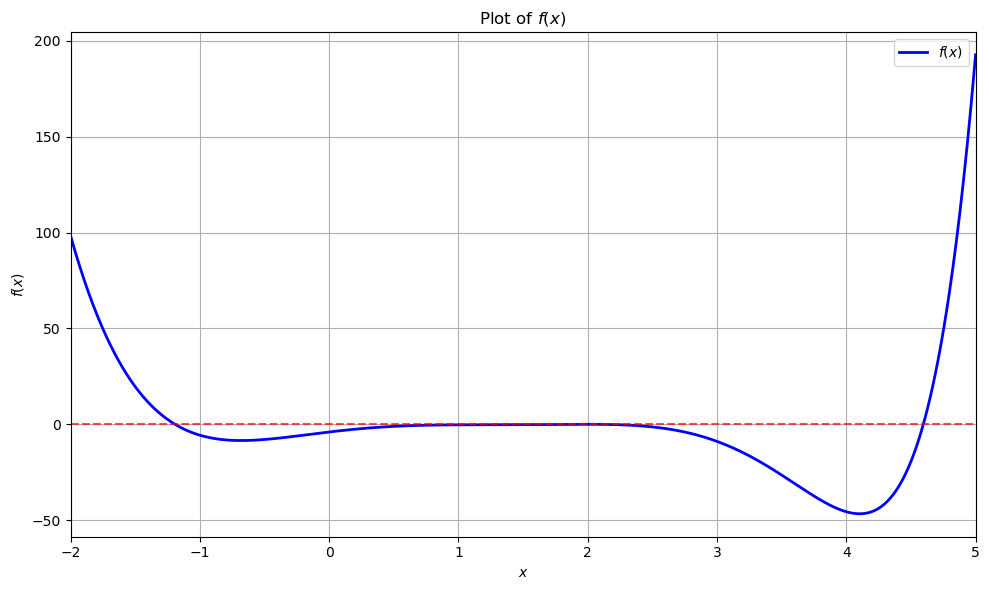

In [86]:
# Function
def f(x):
    return (-(x)**5 + 4*(x)**4 - 4*(x)**3
            + (x**2)*np.exp(x) - 2*(x)**2
            - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8)


# Analytical derivative
def df(x):
    return (-5*x**4 + 16*x**3 - 12*x**2
            - 4*x + 8
            + (x**2 - 2*x)*np.exp(x))

# Plot f(x)
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, color='blue', linewidth=2, label=r'$f(x)$')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.xlim(-2, 5)
plt.xlabel('$x$')
plt.ylabel('$f (x)$')
plt.title('Plot of $f(x)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [89]:
# Fixed-point method (relaxation)
def fixedpoint(f,xold,kmax=200,tol=1.e-8):
    x_values = [xold]
    for k in range(1,kmax):
        xnew = f(xold)
        xdiff = xnew - xold
        x_values.append(xnew)
        if abs(xdiff/xnew) < tol:
            break
        xold = xnew
    else:
        xnew = None
    return xnew, x_values

In [104]:
# Bisection method
def bisection(f, x0, x1, kmax=200, tol=1e-8):
    f0, f1 = f(x0), f(x1)
    if f0*f1 > 0:            
        return None, []
    history = []
    for k in range(1, kmax):
        x2 = (x0 + x1)/2
        f2 = f(x2)
        if f2 == 0:          
            history.append(x2)
            return x2, history
        if f0*f2 < 0:
            x1, f1 = x2, f2
        else:
            x0, f0 = x2, f2
        x2new = (x0 + x1)/2
        history.append(x2new)
        if abs(x2new - x2)/abs(x2new) < tol:
            break
    else:
        x2new = None
    return x2new, history

In [105]:
# Newton's method
def newton(f, df, x0, kmax=200, tol=1.e-8):
    xold = x0
    history = [xold]
    for k in range(1, kmax):
        dfx = df(xold)
        if abs(dfx) < 1e-14:         
            return None, history
        xnew = xold - f(xold)/dfx
        xdiff = xnew - xold
        history.append(xnew)
        if abs(xdiff/xnew) < tol:
            break
        xold = xnew
    else:
        xnew = None
    return xnew, history

In [106]:
# Secant method
def secant(f,x0,x1,kmax=200,tol=1.e-8):
    f0 = f(x0)
    history = [x0, x1]
    for k in range(1,kmax):
        f1 = f(x1)
        if abs(f1 - f0) < 1e-14: 
            break
        ratio = (x1 - x0)/(f1 - f0)
        x2 = x1 - f1*ratio
        xdiff = abs(x2-x1)
        x0, x1 = x1, x2
        f0 = f1

        history.append(x2)
        if abs(xdiff/x2) < tol:
            break
    else:
        x2 = None

    return x2, history

Root 1:
Fixed-Point: -1.1926857629960477
Bisection: -1.1926857605576515
Secant: -1.1926857650225988
Newton: -1.1926857650225988

Root 2:
Fixed-Point: 1.9999999476177657
Bisection: None
Secant: 2.0000000393171709
Newton: 1.9999999791328380

Root 3:
Fixed-Point: 4.5958635547546649
Bisection: 4.5958635509014130
Secant: 4.5958635649223725
Newton: 4.5958635649224542



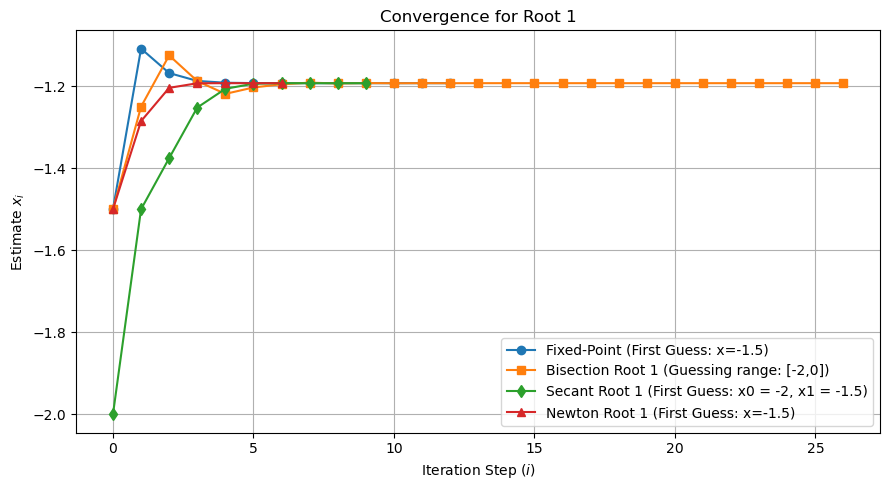

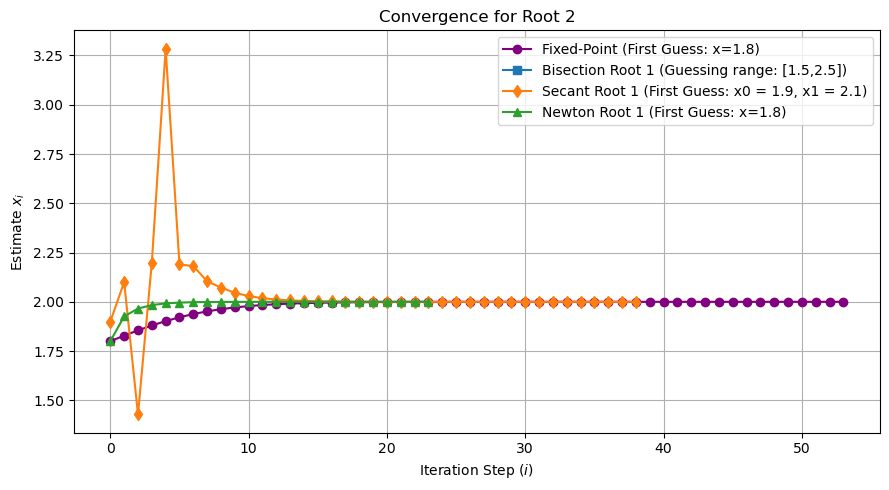

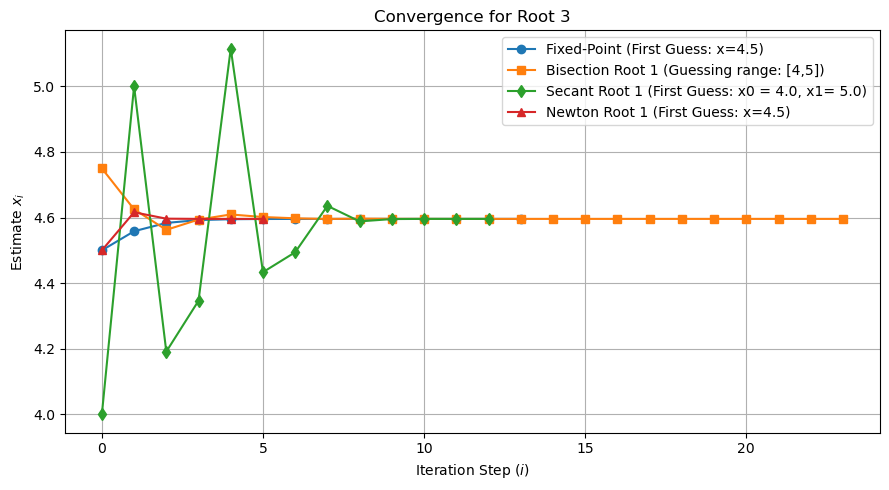

In [113]:
x_values = np.linspace(-2, 5, 500)
y_values = f(x_values)

g1 = lambda x: x + 0.02 * f(x)
g2 = lambda x: x + 0.05 * df(x)
g3 = lambda x: x - 0.003 * f(x)

# Root 1
root1_fp, hist1_fp = fixedpoint(g1, xold=-1.5)
root1_bi, hist1_bi = bisection(f, x0=-2.0, x1=0.0)
root1_sc, hist1_sc = secant(f, x0=-2.0, x1=-1.5)

root1_nt, hist1_nt = newton(f, df, x0=-1.5)
print("Root 1:")
# print(f"Fixed-Point (g1, xold = -1.5)    : x = {root1_fp:.16f}")
print(f"Fixed-Point: {root1_fp:.16f}")
# print(f"Bisection   (x0 = -2, x1 = 0)    : x = {root1_bi:.16f}")
print(f"Bisection: {root1_bi:.16f}")
#print(f"Secant      (x0 = -2, x1 = -1.5) : x = {root1_sc:.16f}")
print(f"Secant: {root1_sc:.16f}")
# print(f"Newton      (x0 = -1.5)          : x = {root1_nt:.16f}\n")
print(f"Newton: {root1_nt:.16f}\n")

# Root 2
root2_fp, hist2_fp = fixedpoint(g2, xold=1.8)
root2_bi, hist2_bi = bisection(f, x0=1.5, x1=2.5) # f'(x) changes sign at double root
root2_sc, hist2_sc = secant(f, x0=1.9, x1=2.1)
root2_nt, hist2_nt = newton(f, df, x0=1.8)

print("Root 2:")
# print(f"Fixed-Point (g2, xold=1.8)       : x = {root2_fp:.16f}") # Added Fixed-Point print statement
print(f"Fixed-Point: {root2_fp:.16f}")
# print(f"Bisection   (f, x0=1.5, x1=2.5)  : x = {root2_bi}")
print(f"Bisection: {root2_bi}")
# print(f"Secant      (x0 = 1.9, x1 = 2.1) : x = {root2_sc:.16f}")
print(f"Secant: {root2_sc:.16f}")
# print(f"Newton      (x0 = 1.8)           : x = {root2_nt:.16f}\n")
print(f"Newton: {root2_nt:.16f}\n")


# Root 3
root3_fp, hist3_fp = fixedpoint(g3, xold=4.5)
root3_bi, hist3_bi = bisection(f, x0=4.0, x1=5.0)
root3_sc, hist3_sc = secant(f, x0=4.0, x1=5.0)
root3_nt, hist3_nt = newton(f, df, x0=4.5)

print("Root 3:")
# print(f"Fixed-Point (g3, xold = 4.5)     : x = {root3_fp:.16f}")
print(f"Fixed-Point: {root3_fp:.16f}")
# print(f"Bisection   (x0 = 4.0, x1= 5.0)  : x = {root3_bi:.16f}")
print(f"Bisection: {root3_bi:.16f}")
# print(f"Secant      (x0 = 4.0, x1= 5.0)  : x = {root3_sc:.16f}")
print(f"Secant: {root3_sc:.16f}")
# print(f"Newton      (x0 = 4.5)           : x = {root3_nt:.16f}\n")
print(f"Newton: {root3_nt:.16f}\n")

# 1. Plot for Root 1
plt.figure(figsize=(9, 5))
plt.plot(hist1_fp, marker='o', label="Fixed-Point (First Guess: x=-1.5)") 
plt.plot(hist1_bi, marker='s', label="Bisection Root 1 (Guessing range: [-2,0])")
plt.plot(hist1_sc, marker='d', label="Secant Root 1 (First Guess: x0 = -2, x1 = -1.5)")
plt.plot(hist1_nt, marker='^', label="Newton Root 1 (First Guess: x=-1.5)")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Estimate $x_i$')
plt.title('Convergence for Root 1')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Plot for Root 2
plt.figure(figsize=(9, 5))
plt.plot(hist2_fp, marker='o', color='purple', label="Fixed-Point (First Guess: x=1.8)") 
plt.plot(hist2_bi, marker='s', label="Bisection Root 1 (Guessing range: [1.5,2.5])")
plt.plot(hist2_sc, marker='d', label="Secant Root 1 (First Guess: x0 = 1.9, x1 = 2.1)")
plt.plot(hist2_nt, marker='^', label="Newton Root 1 (First Guess: x=1.8)")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Estimate $x_i$')
plt.title('Convergence for Root 2')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Plot for Root 3
plt.figure(figsize=(9, 5))
plt.plot(hist3_fp, marker='o', label="Fixed-Point (First Guess: x=4.5)")
plt.plot(hist3_bi, marker='s', label="Bisection Root 1 (Guessing range: [4,5])")
plt.plot(hist3_sc, marker='d', label="Secant Root 1 (First Guess: x0 = 4.0, x1= 5.0)")
plt.plot(hist3_nt, marker='^', label="Newton Root 1 (First Guess: x=4.5)")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Estimate $x_i$')
plt.title('Convergence for Root 3')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---